In [2]:
import numpy as np  
import matplotlib.pyplot as plt
from Utilities import extractor, cb_pdf

#Estraiamo i dati 

x_MH50= extractor("Dati/Tprime_tAq_1800_MH50_LH_2017.root", "Events")

#Filtriamo i dati per rimuovere outliers
x_filtered = 0

In [ ]:
#Capiamo come filtrare i dati
import uproot
import awkward as ak

file=uproot.open("Dati/Tprime_tAq_1800_MH50_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]
print(Fatjet_isMatchedWithA)
print(type(Fatjet_isMatchedWithA))


[[1, 0, 0], [0, 1], [1], [0, 1], [...], ..., [1, 0], [1, 0], [1, 0, 0], [1, 0]]
<class 'awkward.highlevel.Array'>


In [ ]:
#Applichiamo il filtro
mask = ak.flatten(Fatjet_isMatchedWithA) == 1
x_filtered = x_MH50[mask]
print(x_filtered) 
print(type(x_filtered))
print(len(x_filtered))



[49.8, 50.3, 49.3, 51.9, 49.1, 41.4, 50.7, ..., 50.1, 210, 182, 49.4, 59, 49.9]
<class 'awkward.highlevel.Array'>
56168


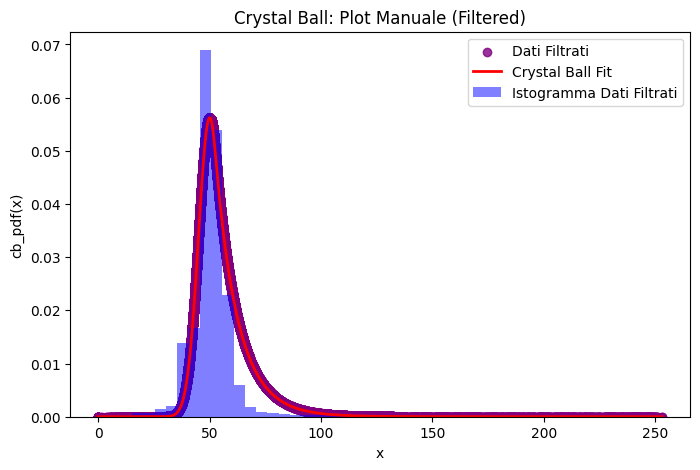

In [28]:
#Facciamo il fit dei dati filtrati

y_filtered=cb_pdf(x_filtered,mu=50,sigma=5,beta=0.5, m=30.0001)

x_plot=list(x_filtered)
x_plot.sort()
y_plot=[cb_pdf(xi,mu=50,sigma=5,beta=0.5, m=30.0001) for xi in x_plot]

fig = plt.figure(figsize=(8, 5))
plt.scatter(x_filtered, y_filtered, color="purple", alpha=0.8, label="Dati Filtrati")
plt.plot(x_plot, y_plot, color="red", alpha=1, linewidth=2, label="Crystal Ball Fit")
plt.hist(x_filtered, bins=50, density=True, alpha=0.5, color="blue", label="Istogramma Dati Filtrati", weights=np.ones_like(x_filtered) / len(x_filtered))
plt.title("Crystal Ball: Plot Manuale (Filtered)")
plt.xlabel("x")
plt.ylabel("cb_pdf(x)")
plt.legend()
plt.show()  


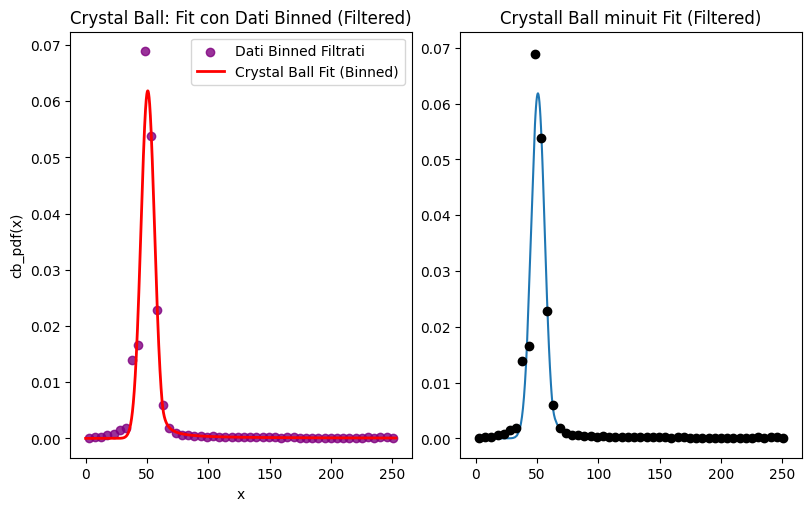

In [36]:
#Ora facciamo il fit con i dati binned
from iminuit import Minuit
from iminuit.cost import LeastSquares


bin_counts, bin_edges = np.histogram(x_plot, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls=LeastSquares(bin_centers, bin_densities, yerr, model=cb_pdf)

m=Minuit(ls, mu=50, sigma=5, beta=0.5, m=30.0001)
m.limits["mu"]= (45, 65)
m.limits["sigma"]= (0.1, 20)
m.limits["beta"]= (0.1, 10)
m.limits["m"]= (0.1, 100)
m.migrad()  

fig, ax= plt.subplots(1, 2, figsize=(8, 5), sharex=True, constrained_layout=True)
plt.sca(ax[0])
plt.scatter(bin_centers, bin_densities, color="purple", alpha=0.8, label="Dati Binned Filtrati")
plt.plot(x_plot, [cb_pdf(xi, *m.values) for xi in x_plot], color="red", alpha=1, linewidth=2, label="Crystal Ball Fit (Binned)")
plt.title("Crystal Ball: Fit con Dati Binned (Filtered)")
plt.xlabel("x")
plt.ylabel("cb_pdf(x)")
plt.legend()    

plt.sca(ax[1])
m.visualize()
plt.title("Crystall Ball minuit Fit (Filtered)")
plt.show()